In [1]:
# JAX notebook: test that for a linear, reciprocal, damped 2nd-order system
# the adjoint field a(t) is the time-reversal of a forward damped solve \tilde a(t),
# i.e.  a(t) = \tilde a(T - t)
#
# Model:
#   M u¨ + C u˙ + K u = f(t)
# Terminal loss (no running loss):
#   J = 0.5||u(T) - uT*||^2 + 0.5||u˙(T) - vT*||^2
#
# Adjoint ODE (homogeneous in this setup):
#   M a¨ - C a˙ + K a = 0
# Terminal conditions:
#   a(T)   = - dJ/d(u˙(T)) = -(u˙(T) - vT*)
#   a˙(T)  = + dJ/d(u(T))  =  (u(T)  - uT*)
#
# Define \tilde a(t) as the forward-time solution of the *forward* damped operator
# with initial conditions:
#   \tilde a(0)  = a(T)
#   \tilde a˙(0) = -a˙(T)
# Then (for constant M,C,K) we should have:  \tilde a(t) = a(T - t).



In [2]:
import jax
import jax.numpy as jnp
from functools import partial

# ----------------------------
# Utilities: RK4 integrator on a fixed grid (JAX-friendly)
# ----------------------------
def rk4_step(f, x, t, dt, params):
    k1 = f(x, t, params)
    k2 = f(x + 0.5 * dt * k1, t + 0.5 * dt, params)
    k3 = f(x + 0.5 * dt * k2, t + 0.5 * dt, params)
    k4 = f(x + dt * k3, t + dt, params)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def integrate_fixed_grid(f, x0, ts, params):
    """Integrate x' = f(x,t) over times ts (1D array). Returns xs with xs[0]=x0."""
    dts = ts[1:] - ts[:-1]

    def body(x, carry):
        t, dt = carry
        x_next = rk4_step(f, x, t, dt, params)
        return x_next, x_next

    xT, xs_tail = jax.lax.scan(body, x0, (ts[:-1], dts))
    xs = jnp.vstack([x0[None, :], xs_tail])
    return xs



In [3]:
# ----------------------------
# Define a damped oscillator network
# ----------------------------
key = jax.random.key(0)
n = 4

# Symmetric positive definite M, C, K (reciprocal)
A = jax.random.normal(key, (n, n))
M = A.T @ A + 0.5 * jnp.eye(n)

B = jax.random.normal(jax.random.split(key, 2)[1], (n, n))
K = B.T @ B + 1.0 * jnp.eye(n)


# # Damping (symmetric positive semidefinite)
# C = 0.2 * jnp.eye(n)
# Damping (symmetric positive definite)
D = jax.random.normal(jax.random.split(key, 3)[1], (n, n))
C = D.T @ D + 0.2 * jnp.eye(n)

Minv = jnp.linalg.inv(M)

# Forcing for the forward run
def forcing(t):
    # forcing only on the first DOF
    f = jnp.zeros(n)
    f = f.at[0].set(jnp.sin(1.0 * t))
    return f

# Forward dynamics in first-order form: x = [u, v]
def f_forward(x, t, params):
    M, C, K, Minv = params
    u = x[:n]
    v = x[n:]
    f = forcing(t)
    u_dot = v
    v_dot = Minv @ (f - C @ v - K @ u)
    return jnp.concatenate([u_dot, v_dot])

# Adjoint dynamics in first-order form: y = [a, b] with b = a_dot
# Adjoint ODE (homogeneous here): M a¨ - C a˙ + K a = 0  ->  a¨ = Minv @ (C a˙ - K a)
def f_adjoint(y, t, params):
    M, C, K, Minv = params
    a = y[:n]
    b = y[n:]
    a_dot = b
    b_dot = Minv @ (C @ b - K @ a)
    return jnp.concatenate([a_dot, b_dot])

# "Tilde-adjoint" forward damped equation: M \tilde a¨ + C \tilde a˙ + K \tilde a = 0
# -> \tilde a¨ = Minv @ (-C \tilde a˙ - K \tilde a)
def f_tilde(z, t, params):
    M, C, K, Minv = params
    at = z[:n]
    bt = z[n:]
    at_dot = bt
    bt_dot = Minv @ (-C @ bt - K @ at)
    return jnp.concatenate([at_dot, bt_dot])

params = (M, C, K, Minv)


2026-02-04 02:36:37.770131: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [4]:

# ----------------------------
# Simulate forward trajectory u(t), v(t)
# ----------------------------
T = 6.0
N = 2000
ts = jnp.linspace(0.0, T, N)

u0 = jnp.zeros((n,))
v0 = jnp.zeros((n,))
x0 = jnp.concatenate([u0, v0])

xs = integrate_fixed_grid(f_forward, x0, ts, params)
uT = xs[-1, :n]
vT = xs[-1, n:]

# Define terminal targets (only on last DOF)
# Set targets equal to actual terminal state, except at last DOF
uT_star = uT.at[-1].set(0.2)   # only last DOF has a target mismatch
vT_star = vT.at[-1].set(-0.1)  # only last DOF has a target mismatch

# Terminal adjoint conditions from J = 0.5||u(T)-u*||^2 + 0.5||v(T)-v*||^2
# These will be zero except at the last DOF
aT = -(vT - vT_star)          # a(T)
aT_dot = (uT - uT_star)       # a_dot(T)

# ----------------------------
# Integrate adjoint backward in time from T to 0
# ----------------------------
# We'll integrate forward on the reversed grid, then flip back.
ts_rev = ts[::-1]

yT = jnp.concatenate([aT, aT_dot])
ys_rev = integrate_fixed_grid(f_adjoint, yT, ts_rev, params)  # evolves from t=T down to 0
ys = ys_rev[::-1]  # now aligned with ts increasing

a = ys[:, :n]
a_dot = ys[:, n:]

# ----------------------------
# Integrate \tilde a forward in time with initial data matching time reversal
# \tilde a(0) = a(T), \tilde a_dot(0) = -a_dot(T)
# ----------------------------
z0 = jnp.concatenate([aT, -aT_dot])
zs = integrate_fixed_grid(f_tilde, z0, ts, params)
a_tilde = zs[:, :n]

# ----------------------------
# Compare: a(t) ?= \tilde a(T - t)
# ----------------------------
a_tilde_time_reversed = a_tilde[::-1]   # \tilde a(T - t) on the grid
err = jnp.max(jnp.linalg.norm(a - a_tilde_time_reversed, axis=1))
rel = err / (jnp.max(jnp.linalg.norm(a, axis=1)) + 1e-12)

print("max || a(t) - tilde_a(T-t) || over t:", float(err))
print("relative max error:", float(rel))

# If everything is correct and RK4 + grid are fine, this should be ~1e-6..1e-9-ish
# (depends on stiffness / dt / conditioning).

max || a(t) - tilde_a(T-t) || over t: 1.404584821784738e-07
relative max error: 7.47794558719761e-07


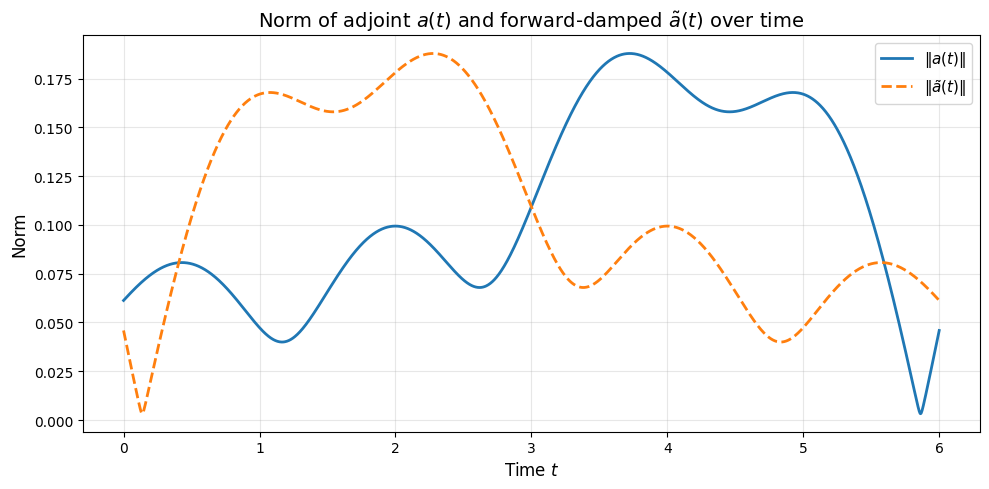

In [5]:
# ----------------------------
# Plot norms of a(t) and tilde_a(t) over time
# ----------------------------
import matplotlib.pyplot as plt

# Compute norms at each time step
norm_a = jnp.linalg.norm(a, axis=1)
norm_a_tilde = jnp.linalg.norm(a_tilde, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(ts, norm_a, label=r'$\|a(t)\|$', linewidth=2)
plt.plot(ts, norm_a_tilde, label=r'$\|\tilde{a}(t)\|$', linewidth=2, linestyle='--')
plt.xlabel('Time $t$', fontsize=12)
plt.ylabel('Norm', fontsize=12)
plt.title(r'Norm of adjoint $a(t)$ and forward-damped $\tilde{a}(t)$ over time', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()